# 第4回講義 演習
今回は，PyTorchを利用して多層パーセプトロンを実装します．

---

# Lecture 4: Exercises
In this exercise, we implement a multilayer perceptron using PyTorch.


## 目次

1. [PyTorchとAutograd](#scrollTo=4l25AL73RsnR)
    
    1.1. [PyTorchとは](#scrollTo=FJXRG3KrRsnS)
    
    1.2. [ライブラリの構成](#scrollTo=sDQqkbU-RsnV)
    
    1.3.[Autograd](#scrollTo=I4bjrlb2RspZ)

1. [PyTorchによるモデルの構築・学習](#scrollTo=5ywYH6dVRsp3)
    
    2.1. [functional](#scrollTo=gHDUoTzCaL_d)
    
    2.2. [Module](#scrollTo=j-ZDoKiNRsp7)

    2.3. [Initialization](#scrollTo=1D5fYkofaL_h)
    
    2.4. [Sequential](#scrollTo=9eaxJjN6wba3)
    
    2.5. [最適化](#scrollTo=TbVmLxISRsqO)
    
    2.6. [学習](#scrollTo=WGIj_4WjRsqQ)
    
    2.7. [モデルの保存・読み込み・再学習](#scrollTo=ldwZW3OGRsqT)

1. [Tips:torchvision & DataLoader](#scrollTo=1Iqz4m4xRsqY)

1. [【課題】PyTorchを使ってMLPを実装](#scrollTo=AqK2mgRbRsqd)
    
    4.1. [モデルなどの定義](#scrollTo=SFXCJ7k6-ElX)
    
    4.2. [Dataloaderの定義](#scrollTo=k6DuaJOCRsqs)

    4.3. [学習](#scrollTo=Q2HAbfalRsq0)

---

## Table of Contents

1. [PyTorch and Autograd](#scrollTo=4l25AL73RsnR)

    1.1. [What is PyTorch?](#scrollTo=FJXRG3KrRsnS)

    1.2. [Library Structure](#scrollTo=sDQqkbU-RsnV)

    1.3. [Autograd](#scrollTo=I4bjrlb2RspZ)

1. [Building and Training Models with PyTorch](#scrollTo=5ywYH6dVRsp3)

    2.1. [functional](#scrollTo=gHDUoTzCaL_d)

    2.2. [Module](#scrollTo=j-ZDoKiNRsp7)

    2.3. [Initialization](#scrollTo=1D5fYkofaL_h)

    2.4. [Sequential](#scrollTo=9eaxJjN6wba3)

    2.5. [Optimisation](#scrollTo=TbVmLxISRsqO)

    2.6. [Training](#scrollTo=WGIj_4WjRsqQ)

    2.7. [Saving / Loading / Retraining Models](#scrollTo=ldwZW3OGRsqT)

1. [Tips: torchvision & DataLoader](#scrollTo=1Iqz4m4xRsqY)

1. [[Assignment] Implement an MLP with PyTorch](#scrollTo=AqK2mgRbRsqd)

    4.1. [Define the Model, etc.](#scrollTo=SFXCJ7k6-ElX)

    4.2. [Define the DataLoader](#scrollTo=k6DuaJOCRsqs)

    4.3. [Training](#scrollTo=Q2HAbfalRsq0)



In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
from pylab import rcParams
rcParams['figure.figsize'] = (5, 3)

from functools import partial
# print() helper that adds two line breaks (for readability)
printn = partial(print, end='\n\n')

seed = 1234
np.random.seed(seed)

## 1.PyTorchとAutograd

---

## 1. PyTorch and Autograd


### 1.1. PyTorchとは

PyTorchは，元々Facebook AI Research (FAIR)によって開発され，現在はオープンソースのニューラルネットワークライブラリです．
TensorFlowでは，ネットワークの計算グラフを定義した後にコンパイルしてからデータを流す (静的フレームワーク) のに対し，PyTorchではデータが流れるごとに計算グラフを動的に構築する (動的フレームワーク) ため，データごとにグラフの形状が異なる自然言語処理などに向いているとされています．

詳しい使い方は事前配布の補足資料を参照してください．  

公式ドキュメント: https://pytorch.org/docs/stable/index.html

---

### 1.1. What is PyTorch?

PyTorch is an open-source neural network library. It was originally developed by Facebook AI Research (FAIR).
Whereas TensorFlow typically defines a computation graph and compiles it before running data through it (a static framework), PyTorch builds the computation graph dynamically as data flows through the model (a dynamic framework). This is considered suitable for tasks such as natural language processing, where the graph structure can vary across inputs.

For details on usage, please refer to the supplementary material provided in advance.  

Official documentation: https://pytorch.org/docs/stable/index.html


### 1.2. ライブラリの構成

---

### 1.2. Library Structure


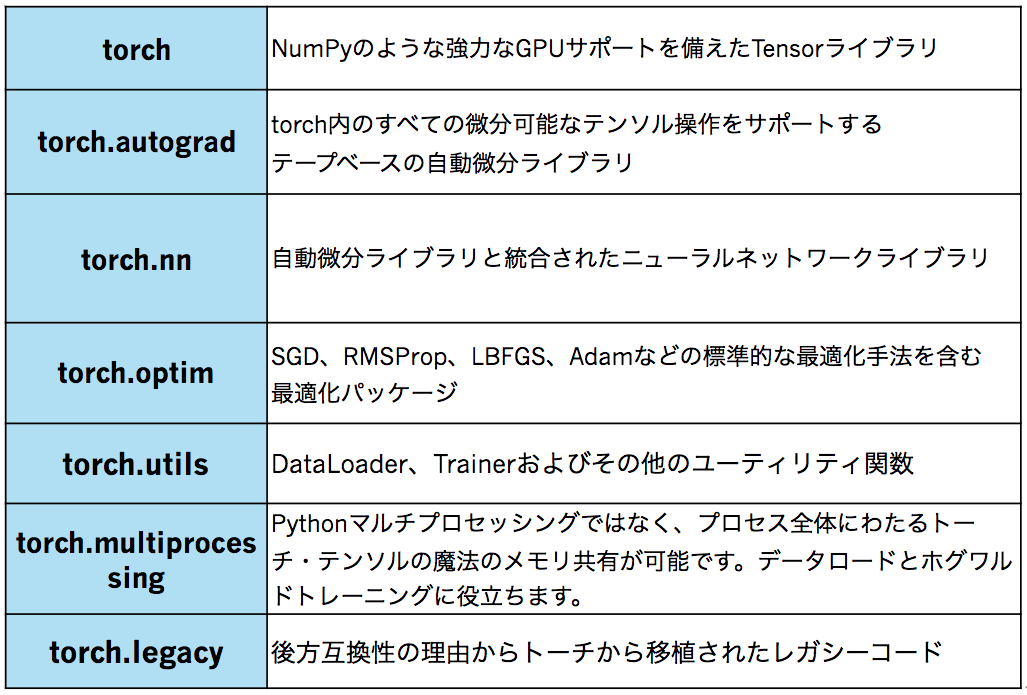

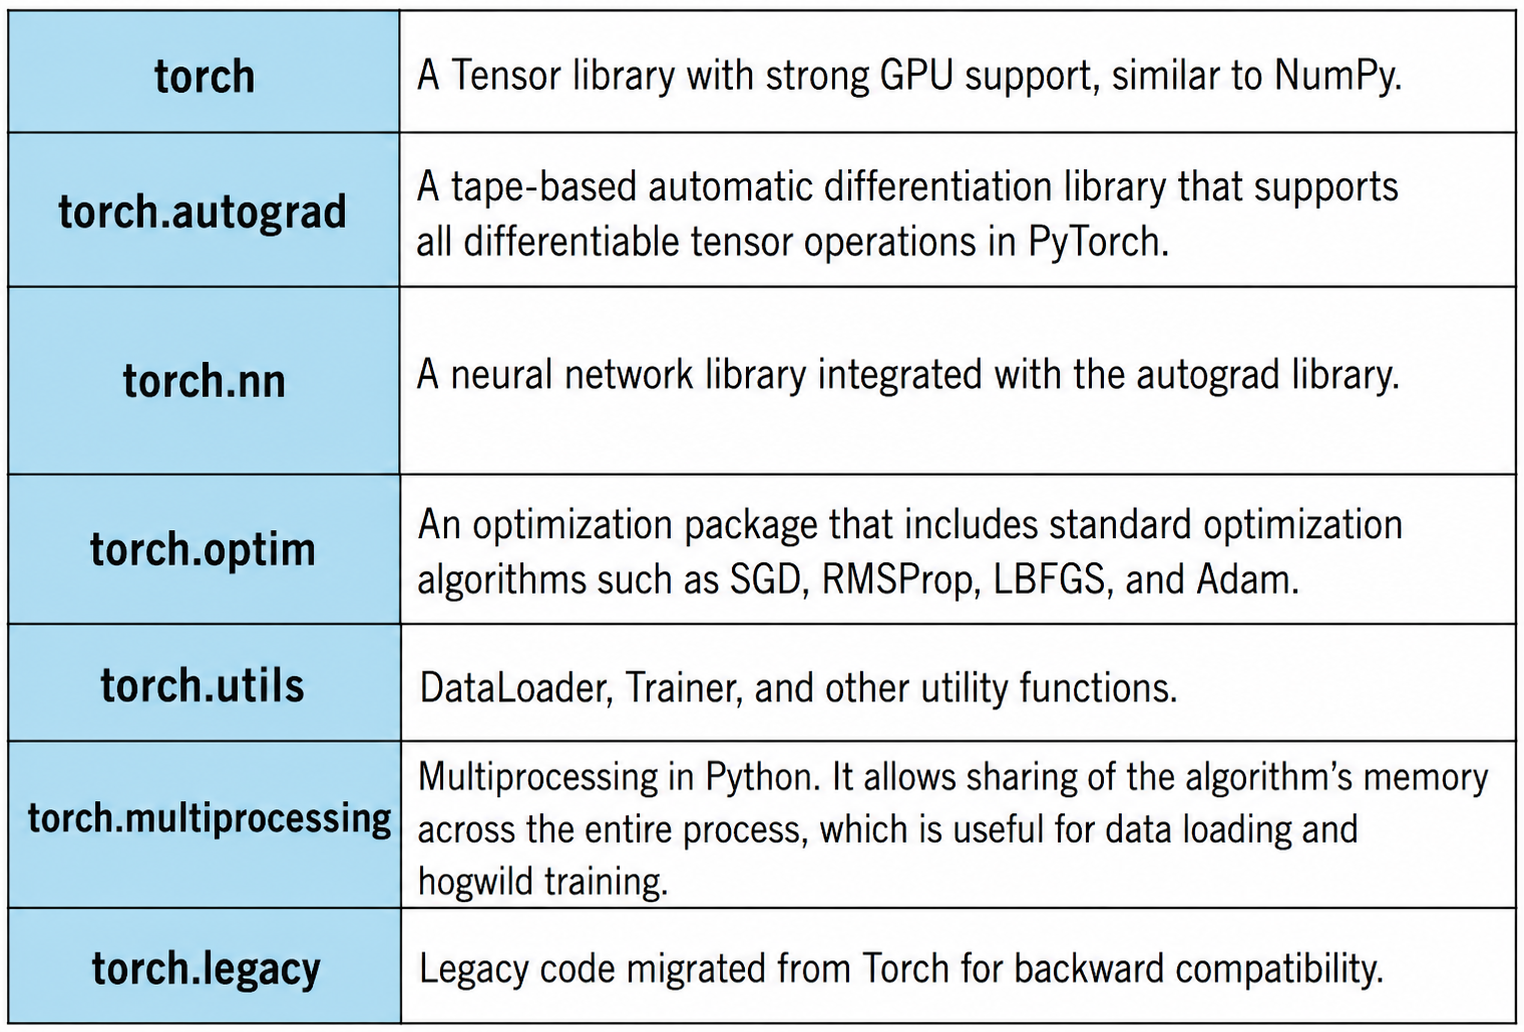

出典: PyTorch公式 (https://pytorch.org/about/)  
Source: PyTorch (official) (https://pytorch.org/about/)

出典: PyTorchのススメ (https://www.slideshare.net/yuyasoneoka/pytorch-80883065)  
Source: "PyTorch no Susume" (https://www.slideshare.net/yuyasoneoka/pytorch-80883065)

### 1.3. Autograd

PyTorchでは，Tensorの自動微分をサポートするautogradの機能が提供されています．

autogradの仕組みを理解する上で重要なクラスとしてFunctionがあります．

FunctionはTensorを入力としてTensorを出力する関数であり，Tensorをノード，Functionをエッジとして計算グラフが構築されます．

各Tensorは`.grad_fn`という属性を有しており，これはそのTensorを作成したFunctionを参照しています．（ユーザが自分で作成したTensorの`.grad_fn`はNoneになります）

---

PyTorch provides autograd, which supports automatic differentiation for tensors.

To understand how autograd works, the Function class is important.

Function is a function that takes tensors as input and outputs tensors. In autograd, a computation graph is built with tensors as nodes and functions as edges.

Each tensor has an attribute called `.grad_fn`, which references the function that created the tensor. (For tensors created directly by the user, `.grad_fn` is None.)

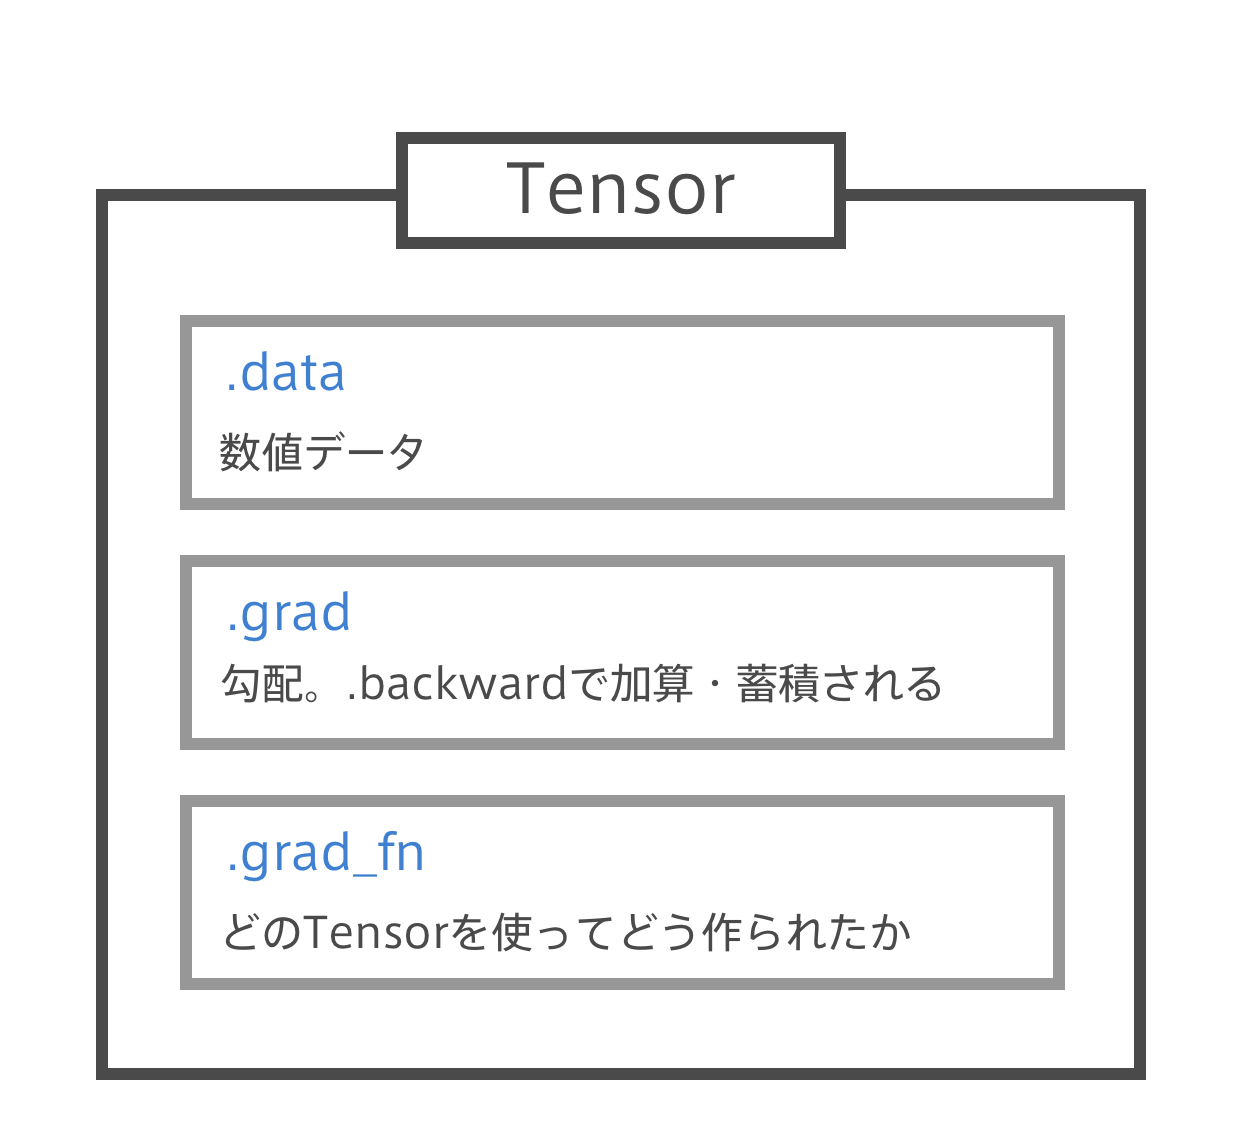

<br>
<br>
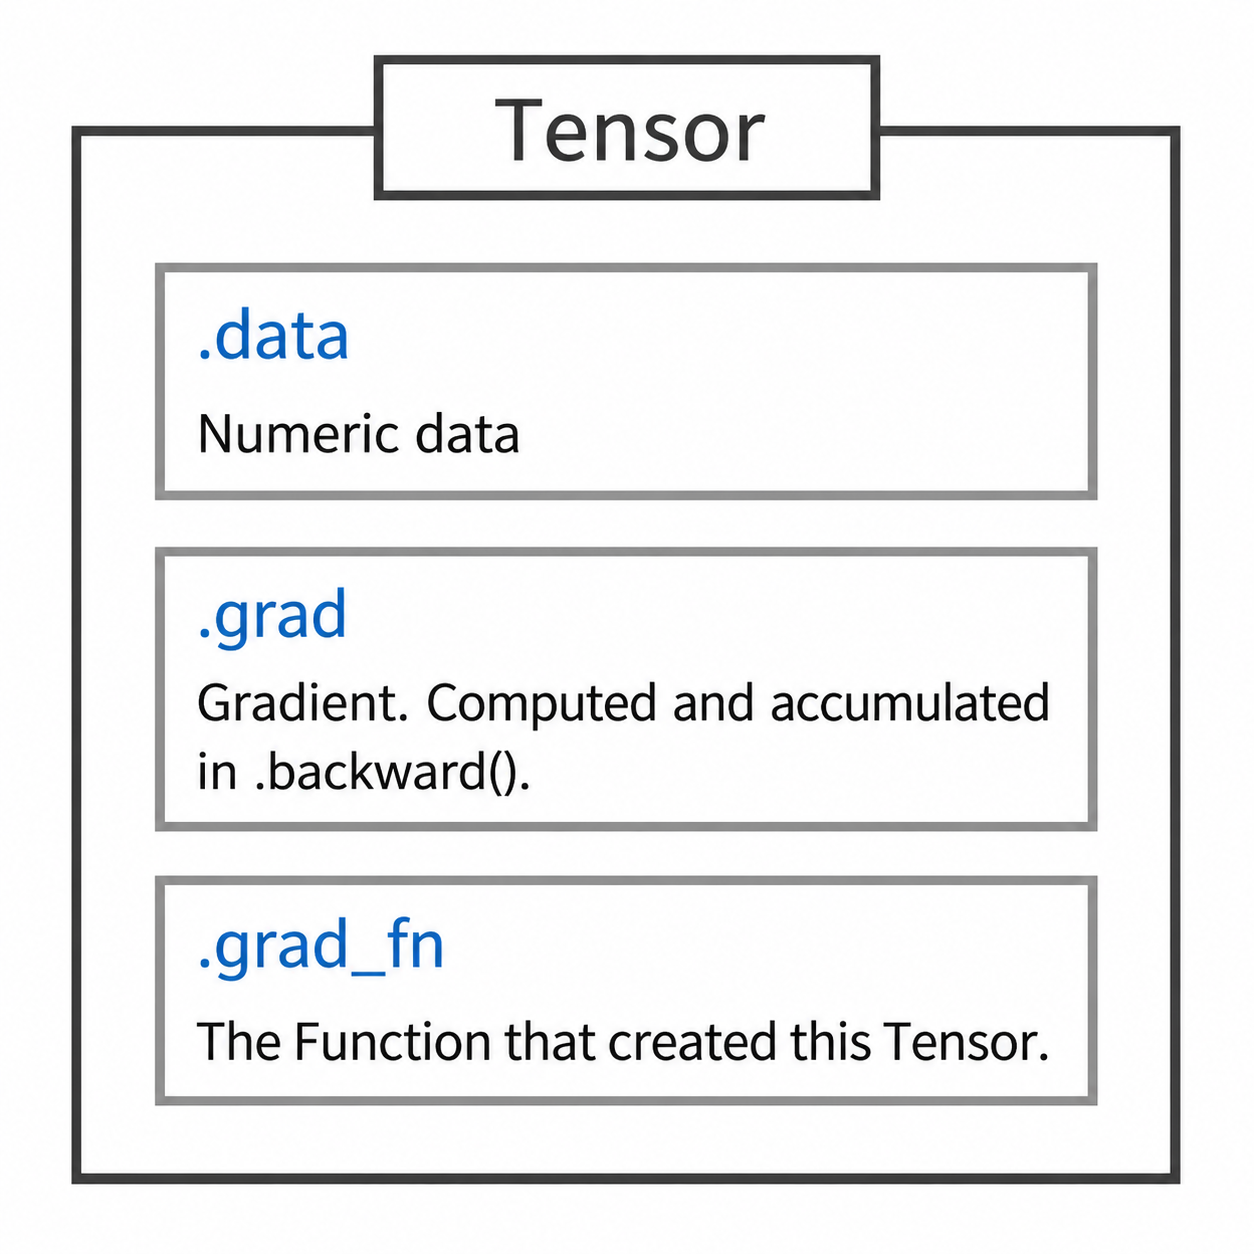



autogradを用いるには，まず計算グラフを構築した後，`forward`関数によって入力のTensorから出力のTensorに対する順伝播の計算を行います．

その後，`backward`関数を呼ぶことにより，`requires_grad=True`を指定したすべてのTensorの目的関数に関する勾配が計算されます．

---

To use autograd, you first build the computation graph and run a forward computation from input tensors to output tensors.

Then, by calling `backward`, PyTorch computes gradients of the objective with respect to all tensors for which `requires_grad=True` was set.

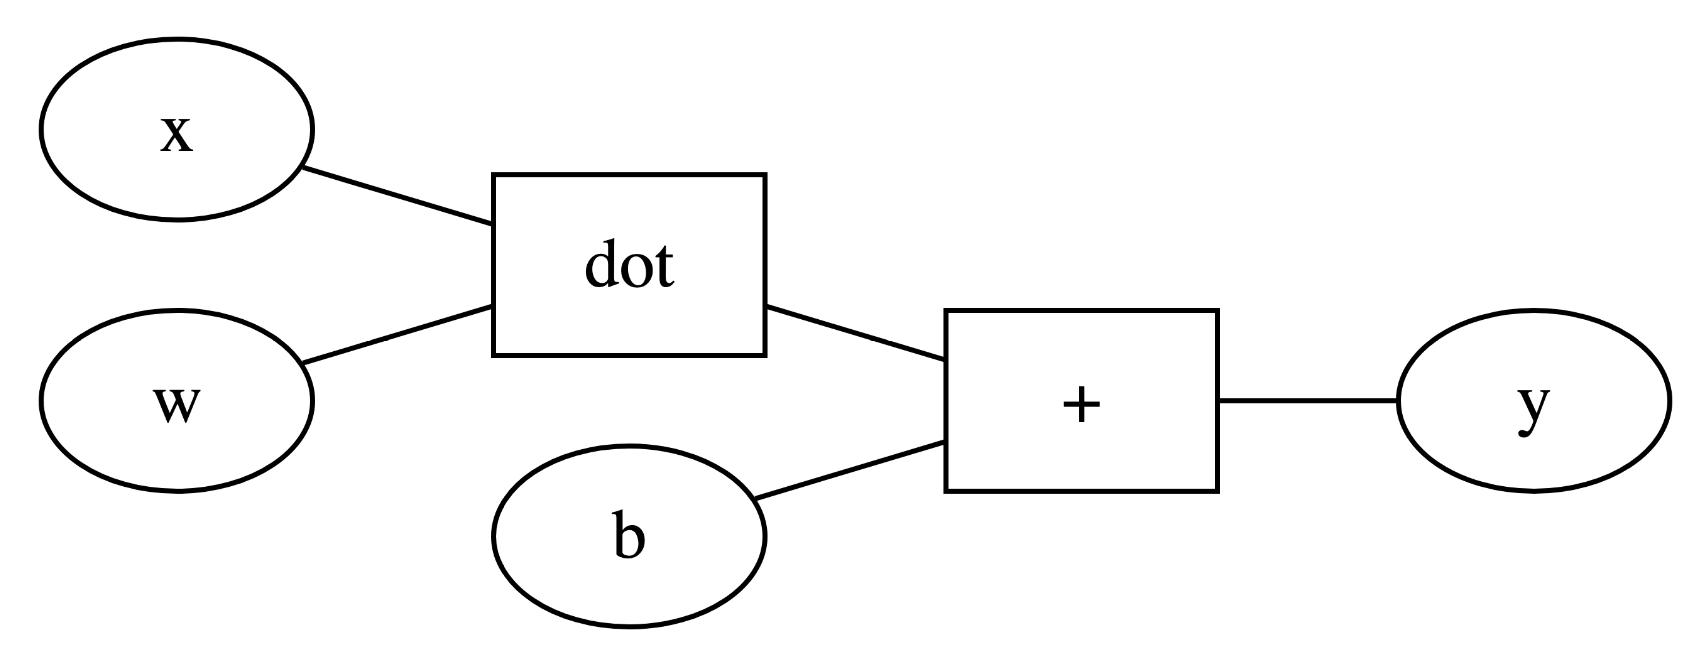


In [ ]:
# Forward pass
x = torch.randn(4, 4)
y = torch.randn(4, 1)

w = torch.randn(4, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

y_pred = torch.matmul(x, w) + b

# Define the objective function
loss = (y_pred - y).pow(2).sum()

In [ ]:
# User-created tensors have grad_fn = None
print(x.grad_fn)
print(y.grad_fn)
print(w.grad_fn)
printn(b.grad_fn)

# Tensors produced by a Function have a grad_fn
print(y_pred.grad_fn)

In [ ]:
# Gradients have not been computed yet
print(x.grad)
print(y.grad)
print(w.grad)
print(b.grad)

In [ ]:
# Backward pass
loss.backward()

In [ ]:
# Tensors with requires_grad=True now have gradients
print(x.grad)
print(y.grad)
print(w.grad)
print(b.grad)

`.detach()`を使うことにより，Tensorの勾配計算を行わないようにすることもできます．  

By using `.detach()`, you can stop gradient computation for a tensor.


In [ ]:
x = torch.randn(4, 4)
y = torch.randn(4, 1)

w = torch.randn(4, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
b = b.detach()  # stop computing gradients for b

y_pred = torch.matmul(x, w) + b

loss = (y_pred - y).pow(2).sum()

loss.backward()

print(w.grad)  # has gradients
print(b.grad)  # has no gradients

また，`with torch.no_grad():`でくくることで，その下で定義したTensorの勾配計算をまとめて停止させることが可能です．

これは，学習済みのモデルを評価する際に，モデルが`requires_grad=True`となっているパラメータを有する場合でも勾配計算を行わないようにしたいときなどに有用です．

---

You can also wrap code with `with torch.no_grad():` to disable gradient computation for all tensors created inside the block.

This is useful, for example, when evaluating a trained model and you want to avoid computing gradients even if the model has parameters with `requires_grad=True`.


In [ ]:
with torch.no_grad():
    y_eval = torch.matmul(x, w) + b  # same computation as y_pred

print('requires_grad of y_pred:', y_pred.requires_grad)  # requires_grad=True
print('requires_grad of y_eval:', y_eval.requires_grad)  # requires_grad=False

## 2.PyTorchによるモデルの構築・学習

---

## 2. Building and Training Models with PyTorch


autogradは自動微分を可能にする強力な機能ですが，巨大なニューラルネットワークを低レベルのautogradのみで実装するのは大変です．

ニューラルネットワークを構築する際には，学習可能なパラメータを有するいくつかのレイヤーを定義することが一般的ですが，PyTorchにはこれを行う上で[torch.nn](https://pytorch.org/docs/stable/nn.html)という便利な高レベルのパッケージが存在します．

今回の演習は実装を理解することを目的としているので，高レベルのAPIを多用しませんが，以下を用いて実装します．

更に[torch.optim](https://pytorch.org/docs/stable/optim.html)を用いてoptimizerを実装することができます．

---

Autograd enables automatic differentiation, but implementing large neural networks only with low-level autograd APIs is cumbersome.

When building neural networks, we typically define layers that have trainable parameters. PyTorch provides a convenient high-level package for this: [torch.nn](https://pytorch.org/docs/stable/nn.html).

Since the goal of this exercise is to understand the implementation, we will not heavily rely on high-level APIs, but we will use the components below.

In addition, we can implement optimisers using [torch.optim](https://pytorch.org/docs/stable/optim.html).


### 2.1. functional

[torch.nn.functional](https://pytorch.org/docs/stable/nn.functional.html)では，`torch.nn`の様々なAPIをインスタンス化せずとも関数として使用することができます．

- 慣習的に`import torch.nn.functional as F`としてimportされます．

活性化関数やプーリング（第5回参照）など，内部に学習可能パラメータを持たないレイヤーは`torch.nn.functional`から呼ぶと便利です．

- 注意すべきものとして，DropoutやBatchNormalizationなど，訓練時と推論時で振る舞いが異なるレイヤーがあります（例えばDropoutは訓練時にしか適用されない）．
  - `nn`からインスタンス化した場合は，訓練・推論時に呼ぶ`model.train()`や`model.eval()`がこれを自動的に切り替えてくれます．
  - ちなみにBatchNormは重みやバイアスとは別に，学習可能パラメータを持ちます．

---

### 2.1. functional

[torch.nn.functional](https://pytorch.org/docs/stable/nn.functional.html) allows you to use many APIs from `torch.nn` as functions without instantiating modules.

- It is conventionally imported as `import torch.nn.functional as F`.

Layers without learnable parameters (e.g., activation functions and pooling (see Lecture 5)) are convenient to call from `torch.nn.functional`.

- Note that some layers, such as Dropout and Batch Normalisation, behave differently during training and inference (e.g., Dropout is applied only during training).
  - If you instantiate them from `nn`, calling `model.train()` or `model.eval()` automatically switches this behaviour.
  - By the way, BatchNorm has learnable parameters in addition to weights and biases.


In [ ]:
# The following are equivalent to use
a = nn.Sigmoid()(torch.tensor([2]))
print(a)

a = F.sigmoid(torch.tensor([2]))
print(a)

### 2.2. Module

`nn`には，ニューラルネットワークにおけるレイヤーのような役目を果たす[nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)が実装されています．

Tensorを入力としてTensorを出力しますが，学習可能なパラメータなどの内部状態を有し，`forward`関数と`backward`関数を有します．

`nn.Module`をスーパークラスとして継承することで，幅広いレイヤーを実装することができます．

---

`nn` implements [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html), which plays the role of a layer in neural networks.

It takes tensors as input and outputs tensors, but it also holds internal state such as learnable parameters, and defines `forward` (and supports backprop through autograd).

By inheriting from `nn.Module` as a superclass, you can implement a wide variety of layers.


[nn.Parameter](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html)でTensorをラップすることで，Tensorがモジュールの学習可能なパラメータとして認識されます．
- `torch.optim`のオプティマイザーに渡される`parameters()`リストに含まれることになります．

これでラップすると，Tensorは勾配情報を持ちます．

何らかの理由でTensorをパラメータを更新しない（勾配を計算しない）状態にしたい場合は，`tensor.requires_grad = False`などで切り替えることができます．

---

[nn.Parameter](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) wraps a tensor so that it is recognised as a learnable parameter of a module.
- It will be included in the list returned by `parameters()`, which is passed to optimisers in `torch.optim`.

Once wrapped, the tensor will carry gradient information.

If for some reason you want to keep a tensor as a parameter but stop updating it (i.e., stop computing gradients), you can switch it off via `tensor.requires_grad = False`, etc.


In [ ]:
# By default, a tensor does not require gradients
a = torch.zeros(1)
print(a.requires_grad)

# Wrapping with nn.Parameter makes it a learnable parameter (requires gradients)
a = nn.Parameter(a)
print(a.requires_grad)

# Turn off gradient computation for this tensor
a.requires_grad = False
print(a.requires_grad)

全結合層は，`__init__`と`forward`をoverrideすることで実装できます．  

A fully connected (dense) layer can be implemented by overriding `__init__` and `forward`.


In [ ]:
def relu(x):
    x = torch.where(x > 0, x, torch.zeros_like(x))
    return x


def softmax(x):
    x -= torch.cat([x.max(axis=1, keepdim=True).values] * x.size()[1], dim=1)
    x_exp = torch.exp(x)
    return x_exp/torch.cat([x_exp.sum(dim=1, keepdim=True)] * x.size()[1], dim=1)


class Dense(nn.Module):  # inherit from nn.Module
    def __init__(self, in_dim, out_dim, function=lambda x: x):
        super().__init__()
        # He Initialization
        # in_dim: input dimension, out_dim: output dimension
        self.W = nn.Parameter(torch.tensor(np.random.uniform(
                        low=-np.sqrt(6/in_dim),
                        high=np.sqrt(6/in_dim),
                        size=(in_dim, out_dim)
                    ).astype('float32')))
        self.b = nn.Parameter(torch.tensor(np.zeros([out_dim]).astype('float32')))
        self.function = function

    def forward(self, x):  # override forward
        return self.function(torch.matmul(x, self.W) + self.b)

あらかじめ定義されたレイヤーを用いて，新たなモジュールを定義することもできます．  

You can also define a new module by composing pre-defined layers.


In [ ]:
class MLP(nn.Module):  # inherit from nn.Module
    def __init__(self, in_dim, hid_dim, out_dim):  # override __init__
        super(MLP, self).__init__()
        self.linear1 = Dense(in_dim, hid_dim, function=relu)
        self.linear2 = Dense(hid_dim, out_dim, function=softmax)

    def forward(self, x):  # override forward
        x = self.linear1(x)
        x = self.linear2(x)
        return x

### 2.3. Initialization

2.2.の例ではHe (= Kaiming) initializationを自前で実装していますが，[nn.init](https://pytorch.org/docs/stable/nn.init.html)にTensorを渡すことで，色々な分布で初期化することができます．

- Xavier initialization [[Glorot & Bengio, 2010](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)]は活性化関数がtanhやシグモイドのとき

- He initialization [[He et al., 2015](https://arxiv.org/pdf/1502.01852.pdf)]は活性化関数がReLUのとき

これは活性化関数がゼロ付近で線形と見做せるかどうかの違いから来ます．
  
He, XavierともにUniformとNormalがありますが，基本的に活性化前後での分散を一定にすることが目的なので，明確にどちらが良いということはありません．

---

### 2.3. Initialization

In the example in 2.2, we implemented He (Kaiming) initialisation manually, but you can initialise tensors with various distributions by using [nn.init](https://pytorch.org/docs/stable/nn.init.html).

- Xavier initialisation [[Glorot & Bengio, 2010](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)] is commonly used when the activation is tanh or sigmoid.

- He initialisation [[He et al., 2015](https://arxiv.org/pdf/1502.01852.pdf)] is commonly used when the activation is ReLU.

This difference comes from whether the activation function can be regarded as approximately linear around zero.

Both Xavier and He have Uniform and Normal variants. Since the goal is to keep the variance roughly constant across layers, there is no universally best choice.


**Xavier Uniform**

  - $n_{in}$は層 $l$ のノード数，$n_{out}$は層 $l+1$ のノード数（以後同様）
  - $n_{in}$ is the number of nodes in layer $l$, and $n_{out}$ is the number of nodes in layer $l+1$ (same below).

$$
w_{i,j}^{l} \sim Uniform \left( - \sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}} \right)
$$



In [ ]:
a = torch.zeros(32, 16)
nn.init.xavier_uniform_(a)
plt.hist(a.flatten(), bins=100)
print(f"Mean: {a.mean()} | Std: {a.std()}")

**He (Kaiming) Uniform**

$$
w_{i,j}^{l} \sim Uniform \left( - \sqrt{\frac{6}{n_{in}}}, \sqrt{\frac{6}{n_{in}}} \right)
$$

In [ ]:
a = torch.zeros(32, 16)
nn.init.kaiming_uniform_(a)
plt.hist(a.flatten(), bins=100)
print(f"Mean: {a.mean()} | Std: {a.std()}")

**Xavier Normal**

$$
w_{i,j}^{l} \sim \mathscr{N} \left( 0, \frac{2}{n_{in} + n_{out}} \right)
$$

In [ ]:
a = torch.zeros(32, 16)
nn.init.xavier_normal_(a)
plt.hist(a.flatten(), bins=100)
print(f"Mean: {a.mean()} | Std: {a.std()}")

**He (Kaiming) Normal**

$$
w_{i,j}^{l} \sim \mathscr{N} \left( 0, \frac{2}{n_{in}} \right)
$$

In [ ]:
a = torch.zeros(32, 16)
nn.init.kaiming_normal_(a)
plt.hist(a.flatten(), bins=100)
print(f"Mean: {a.mean()} | Std: {a.std()}")

### 2.4. Sequential

`nn`には[Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)が用意されています．これを用いることで，あらかじめ定義されたレイヤーを重ねて多層ネットワークを定義することができます．  

`nn` provides [Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html). Using it, you can define a multilayer network by stacking pre-defined layers.


In [ ]:
mlp = nn.Sequential(
    Dense(2, 3, relu),  # stack our custom dense layers to build a 2-layer network
    Dense(3, 2, softmax),
)

# You can also define the same network with: mlp = MLP(2, 3, 2)

printn(mlp)

x = torch.Tensor([[0, 0], [0, 1], [1, 0], [1, 1]])
y = mlp(x)  # calls forward(x)
print("# feedforward：")
printn(y)

print("# Get model parameters via mlp.parameters():")
print(mlp.parameters())

### 2.5. 最適化

---

### 2.5. Optimisation


[torch.optim](https://pytorch.org/docs/stable/optim.html)に一般的なoptimizerが実装されています．

勾配のリセットは`.zero_grad()`で，パラメータの更新は`.step()`で行います．

---

[torch.optim](https://pytorch.org/docs/stable/optim.html) provides common optimisers.

Reset gradients with `.zero_grad()`, and update parameters with `.step()`.


```python
# Define the optimizer
optimizer = optim.SGD([W1, W2], lr=0.1)

# Reset gradients
optimizer.zero_grad()

# Update parameters
optimizer.step()
```

### 2.6. 学習

---

### 2.6. Training


これまで見てきたモジュールなどを用いてMLPのモデルを学習させる一連の流れを実装します．  

Using the modules we have seen so far, we implement the full workflow to train an MLP model.


In [ ]:
# XOR dataset
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float)
t = torch.tensor([0, 1, 1, 0], dtype=torch.long)

# Define the model
mlp = MLP(2, 3, 2)

# Define the optimiser
optimizer = optim.SGD(mlp.parameters(), lr=0.1)  # module parameters are obtained via .parameters()

# Set the model to training mode (relevant for Dropout, etc.)
mlp.train()

for i in range(1000):

    t_hot = torch.eye(2)[t]  # convert labels to one-hot vectors

    # Forward pass
    y_pred = mlp(x)

    # Compute loss (cross-entropy)
    loss = -(t_hot*torch.log(y_pred)).sum(dim=1).mean()

    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Update parameters
    optimizer.step()

    if i % 100 == 0:
        print(i, loss.item())

### 2.7. モデルの保存・読み込み・再学習

---

### 2.7. Saving / Loading / Retraining Models


モデルを保存する際には，`torch.save()`を用いますが，モデルのインスタンスを直接保存するのではなく，モデルのパラメータの情報を有するstate_dictを保存し，読み込む際にもstate_dictを読み込んでモデルのインスタンスにloadするのが一般的です．  

When saving a model, we use `torch.save()`. However, it is common practice not to save the model instance directly, but to save the model's `state_dict`, which contains the parameter values. When loading, we load the `state_dict` and then call `load_state_dict` on the model instance.


In [ ]:
printn(list(mlp.parameters()))

# Get the state_dict
state_dict = mlp.state_dict()
print(state_dict)

# Save the model
torch.save(state_dict, '../model.pth')

In [ ]:
# Define the model
mlp2 = MLP(2, 3, 2)
print(list(mlp2.parameters()))  # Random initial values

# Load trained parameters
state_dict = torch.load('../model.pth')
mlp2.load_state_dict(state_dict)
print(list(mlp2.parameters()))  # Trained parameters

## 3.Tips: torchvision & DataLoader

```python
from torchvision import transforms, datasets

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(in_dim))
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('~/data/mnist', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)
```

## 4.【課題】PyTorchを使ってMLPを実装

---

## 4. [Assignment] Implement an MLP with PyTorch


### 4.1. モデルなどの定義

---

### 4.1. Define the Model, etc.


torchvisionは画像認識のためのデータセットや前処理，学習済みモデルなどが収められたPyTorch公式のライブラリです．

MNISTなどのよく使われるデータセットを`torchvision.datasets`から簡単に読み込めるほか，前処理は`transform`としてまとめて`torch.utils.data.DataLoader`に渡すだけでOKです．

MNISTを使用する際の例を以下に示します．

---

torchvision is an official PyTorch library that provides datasets, preprocessing utilities, and pretrained models for computer vision.

You can easily load common datasets such as MNIST from `torchvision.datasets`. Preprocessing can be grouped as a `transform` and passed to `torch.utils.data.DataLoader`.

An example for using MNIST is shown below.


In [ ]:
from torchvision import datasets, transforms

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim):
        super(MLP, self).__init__()
        self.linear1 =  # WRITE ME
        self.linear2 =  # WRITE ME

    def forward(self, x):
        x =  # WRITE ME
        x =  # WRITE ME
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
in_dim = 784
hid_dim = 200
out_dim = 10
lr = 0.001
batch_size = 32
n_epochs = 10


mlp = MLP(in_dim, hid_dim, out_dim).to(device)

optimizer = optim.SGD(mlp.parameters(), lr=lr)

### 4.2. DataLoaderの定義

---

### 4.2. Define the DataLoader


In [ ]:
# Define preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(in_dim))
])

# Load MNIST using torchvision.datasets
# Define a DataLoader that handles mini-batching and preprocessing
dataloader_train = torch.utils.data.DataLoader(
    datasets.MNIST('../data/mnist', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)

dataloader_valid = torch.utils.data.DataLoader(
    datasets.MNIST('../data/mnist', train=False, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=False
)

### 4.3. 学習

---

### 4.3. Training


In [ ]:
for epoch in range(n_epochs):
    losses_train = []
    losses_valid = []
    train_num = 0
    train_true_num = 0
    valid_num = 0
    valid_true_num = 0

    mlp.train()  # Training mode (compute gradients)
    for x, t in dataloader_train:
        # Convert labels to one-hot vectors
        t_hot =  # WRITE ME

        # Move tensors to GPU
        x =  # WRITE ME
        t_hot =  # WRITE ME

        # Forward pass
        y =  # WRITE ME

        # Compute loss (cross-entropy)
        loss =  # WRITE ME

        # Backpropagate the loss
          # WRITE ME
          # WRITE ME

        # Update parameters
          # WRITE ME

        # Convert the model output to scalar class predictions
        pred =  # WRITE ME

        losses_train.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        train_num += acc.size()[0]
        train_true_num += acc.sum().item()

    mlp.eval()  # Switch to eval mode (do not compute gradients during evaluation)
    for x, t in dataloader_valid:
        t_hot = torch.eye(10)[t]  # Convert labels to one-hot vectors

        # Move tensors to GPU
        x = x.to(device)
        t_hot = t_hot.to(device)

        # Forward pass
        y = mlp(x)

        # Compute loss (cross-entropy)
        loss = -(t_hot * torch.log(y)).sum(dim=1).mean()

        # Convert the model output to scalar class predictions
        pred = y.argmax(1)

        losses_valid.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        valid_num += acc.size()[0]
        valid_true_num += acc.sum().item()

    print('EPOCH: {}, Train [Loss: {:.3f}, Accuracy: {:.3f}], Valid [Loss: {:.3f}, Accuracy: {:.3f}]'.format(
        epoch,
        np.mean(losses_train),
        train_true_num / train_num,
        np.mean(losses_valid),
        valid_true_num / valid_num
    ))